# Modelo no supervisado: segmentación de clientes mediante K-Means

## Objetivo

El objetivo de este análisis es identificar segmentos de clientes con características similares mediante el algoritmo de clustering K-Means. A diferencia de los modelos supervisados, este método no utiliza una variable objetivo para aprender a clasificar los registros.

La segmentación permitirá explorar perfiles de clientes según su antigüedad, cargos mensuales, cargos acumulados y características de los servicios contratados. Posteriormente, se analizará la distribución del abandono en cada grupo para identificar segmentos que puedan requerir estrategias comerciales diferenciadas.

## Consideraciones metodológicas

* Se utilizará el conjunto Train para ajustar el algoritmo.
* La variable `Churn` no se utilizará para formar los grupos.
* La variable `customerID` se excluirá por ser un identificador.
* Las variables numéricas se escalarán para evitar que las diferencias de magnitud dominen las distancias.
* La cantidad de grupos se evaluará mediante el método del codo y el coeficiente Silhouette.

El resultado será una segmentación exploratoria, no una predicción individual de abandono.


In [32]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

ROOT = Path.cwd().parent

train = pd.read_csv(
    ROOT / "data" / "split" / "telco_train.csv"
)

# Limpieza determinista de los datos
for column in train.select_dtypes(
    include=["object", "string"]
).columns:
    train[column] = train[column].astype("string").str.strip()

train["TotalCharges"] = pd.to_numeric(
    train["TotalCharges"],
    errors="coerce"
)

train["TotalCharges"] = train["TotalCharges"].fillna(0)

print("Registros Train:", len(train))
print("Columnas originales:", train.shape[1])
print("Clientes duplicados:", train["customerID"].duplicated().sum())
print("Valores faltantes:", train.isna().sum().sum())

display(train.head())

Registros Train: 5634
Columnas originales: 21
Clientes duplicados: 0
Valores faltantes: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No


## Preparar las variables para clustering

In [33]:
# Separar variables de análisis de las columnas que no deben
# participar en la formación de los grupos.

columnas_excluir = ["customerID", "Churn"]

X_cluster = train.drop(
    columns=columnas_excluir
).copy()

# Identificar variables numéricas y categóricas
columnas_numericas = X_cluster.select_dtypes(
    include=["number"]
).columns.tolist()

columnas_categoricas = X_cluster.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Variables numéricas:", columnas_numericas)
print("Cantidad de variables numéricas:", len(columnas_numericas))
print("Cantidad de variables categóricas:", len(columnas_categoricas))
print("Churn está excluida:", "Churn" not in X_cluster.columns)
print("customerID está excluida:", "customerID" not in X_cluster.columns)

preprocesador_cluster = ColumnTransformer(
    transformers=[
        (
            "numericas",
            RobustScaler(),
            columnas_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            columnas_categoricas
        )
    ],
    remainder="drop"
)

X_cluster_preparado = preprocesador_cluster.fit_transform(
    X_cluster
)

print("Dimensiones después del preprocesamiento:",
      X_cluster_preparado.shape)
print("¿Existen valores no finitos?:",
      not np.isfinite(X_cluster_preparado).all())

Variables numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Cantidad de variables numéricas: 4
Cantidad de variables categóricas: 15
Churn está excluida: True
customerID está excluida: True
Dimensiones después del preprocesamiento: (5634, 45)
¿Existen valores no finitos?: False


### Preparación de las variables

Para construir los grupos se excluyen `Churn` y `customerID`. De esta forma, el algoritmo identifica similitudes a partir de las características de los clientes, sin conocer previamente si abandonaron o no el servicio.

Las variables numéricas se transforman mediante `RobustScaler`, que utiliza estadísticas robustas frente a valores extremos. Las variables categóricas se convierten a una representación numérica mediante One-Hot Encoding.

Este paso es necesario porque K-Means trabaja con distancias numéricas y las variables originales tienen distintos formatos y escalas.


## Determinar la cantidad de grupos

In [34]:
valores_k = range(2, 9)

inercia = []
silhouette_scores = []

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = kmeans.fit_predict(X_cluster_preparado)

    inercia.append(kmeans.inertia_)

    score = silhouette_score(
        X_cluster_preparado,
        etiquetas,
        sample_size=min(2000, len(X_cluster_preparado)),
        random_state=42
    )

    silhouette_scores.append(score)

    print(
        f"k={k} | Inercia={kmeans.inertia_:.2f} "
        f"| Silhouette={score:.4f}"
    )

resultados_k = pd.DataFrame({
    "Cantidad de grupos (k)": list(valores_k),
    "Inercia": inercia,
    "Silhouette": silhouette_scores
})

display(resultados_k.round(4))

k=2 | Inercia=41922.85 | Silhouette=0.2492
k=3 | Inercia=35733.02 | Silhouette=0.2194
k=4 | Inercia=33349.64 | Silhouette=0.1878
k=5 | Inercia=31883.48 | Silhouette=0.1743
k=6 | Inercia=30842.91 | Silhouette=0.1665
k=7 | Inercia=29951.98 | Silhouette=0.1188
k=8 | Inercia=28982.63 | Silhouette=0.1096


,Cantidad de grupos (k),Inercia,Silhouette
0,2,41922.8466,0.2492
1,3,35733.0217,0.2194
2,4,33349.6366,0.1878
3,5,31883.4839,0.1743
4,6,30842.9051,0.1665
5,7,29951.9766,0.1188
6,8,28982.6272,0.1096


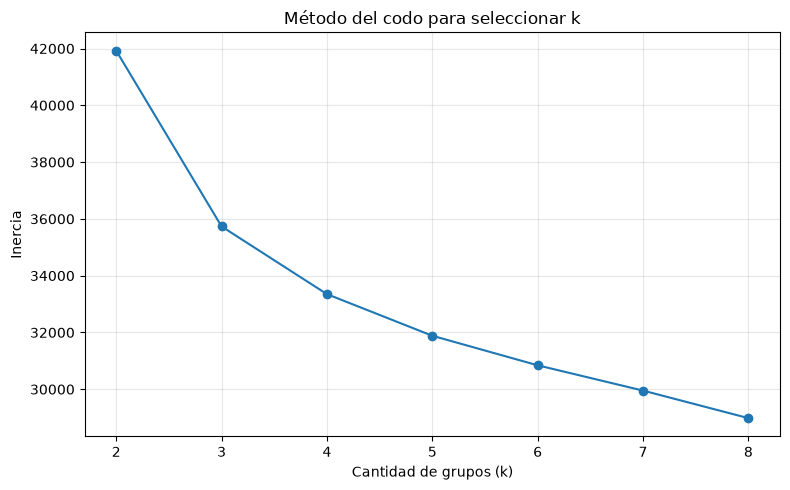

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(valores_k),
    inercia,
    marker="o"
)

plt.title("Método del codo para seleccionar k")
plt.xlabel("Cantidad de grupos (k)")
plt.ylabel("Inercia")
plt.xticks(list(valores_k))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación del método del codo

El gráfico muestra que la inercia disminuye a medida que aumenta la cantidad de grupos. La mayor reducción se observa al pasar de 2 a 3 clusters, cuando la inercia baja de 41.922,85 a 35.733,02. Posteriormente, las reducciones son progresivamente menores.

Se observa que la curva comienza a suavizarse aproximadamente entre 3 y 4 grupos, aunque no presenta un punto de inflexión completamente definido. Por esta razón, el método del codo no permite determinar por sí solo una cantidad óptima de clusters.

Se complementará este resultado con el coeficiente Silhouette para seleccionar una segmentación que equilibre la separación de los grupos y la simplicidad del modelo.


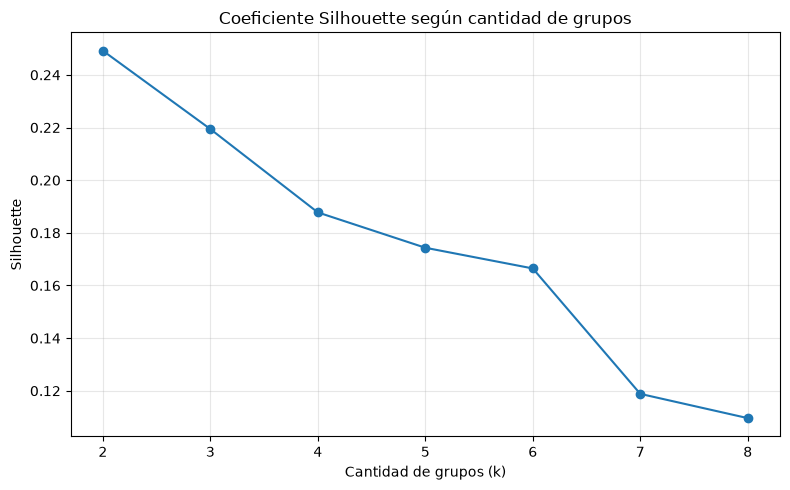

k con mayor Silhouette: 2
Mejor Silhouette: 0.2492


In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(valores_k),
    silhouette_scores,
    marker="o"
)

plt.title("Coeficiente Silhouette según cantidad de grupos")
plt.xlabel("Cantidad de grupos (k)")
plt.ylabel("Silhouette")
plt.xticks(list(valores_k))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

mejor_k_silhouette = list(valores_k)[
    int(np.argmax(silhouette_scores))
]

print("k con mayor Silhouette:", mejor_k_silhouette)
print(
    "Mejor Silhouette:",
    round(max(silhouette_scores), 4)
)

### Interpretación del coeficiente Silhouette

El mayor coeficiente Silhouette se obtiene con 2 grupos, alcanzando un valor de 0,2492. A partir de ese punto, el indicador disminuye progresivamente: llega a 0,2194 con 3 grupos y a 0,1878 con 4 grupos, hasta alcanzar 0,1096 con 8 grupos.

Estos resultados indican que, dentro de las alternativas evaluadas, la segmentación en 2 grupos presenta la mejor separación relativa. Sin embargo, el valor de 0,2492 también sugiere que existe solapamiento entre los segmentos y que la estructura de los grupos no es especialmente marcada.

Por lo tanto, se seleccionarán inicialmente 2 clusters para facilitar la interpretación y evitar aumentar la cantidad de grupos cuando ello reduce la calidad de separación medida por Silhouette. Esta decisión deberá validarse revisando las características y la distribución de los clientes de cada segmento.


## Entrenar el modelo K-Means definitivo

In [37]:
K_FINAL = 2

modelo_kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=42,
    n_init=10
)

clusters = modelo_kmeans.fit_predict(
    X_cluster_preparado
)

train_segmentado = train.copy()
train_segmentado["Cluster"] = clusters

print("Cantidad de grupos:", K_FINAL)
display(
    train_segmentado["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Cantidad de clientes")
    .to_frame()
)

Cantidad de grupos: 2


,Cantidad de clientes
Cluster,
0,1214
1,4420


## Analizar los perfiles de cada grupo

In [38]:
columnas_numericas_originales = (
    train_segmentado
    .select_dtypes(include=["number"])
    .columns
    .drop("Cluster", errors="ignore")
    .tolist()
)

perfil_numerico = (
    train_segmentado
    .groupby("Cluster")[columnas_numericas_originales]
    .mean()
    .round(2)
)

display(perfil_numerico)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Cluster,,,,
0,0.03,30.22,21.11,657.12
1,0.20,33.11,76.96,2750.39


### Interpretación de los perfiles numéricos de los clusters

El análisis de los promedios permite identificar diferencias entre los segmentos. El Cluster 0 presenta cargos mensuales promedio de 21,11 y cargos acumulados de 657,12, mientras que el Cluster 1 registra cargos mensuales de 76,96 y cargos acumulados de 2.750,39.

La antigüedad promedio es relativamente similar entre ambos grupos: 30,22 meses en el Cluster 0 y 33,11 meses en el Cluster 1. Por tanto, la diferencia observada en el abandono no parece explicarse únicamente por la antigüedad promedio.

También se observa una mayor proporción de clientes con `SeniorCitizen = 1` en el Cluster 1. Esta característica puede describirse como parte del perfil del segmento, pero no permite afirmar que la edad sea la causa del abandono.

En conjunto, el Cluster 1 se caracteriza por cargos mensuales y acumulados más elevados y una mayor tasa de abandono. Estas diferencias justifican investigar con mayor detalle qué servicios y condiciones contractuales predominan en dicho grupo.


In [39]:
columnas_categoricas_originales = [
    columna
    for columna in columnas_categoricas
    if columna in train_segmentado.columns
]

for columna in columnas_categoricas_originales:
    print(f"\nDistribución de {columna} por cluster:")

    tabla = pd.crosstab(
        train_segmentado["Cluster"],
        train_segmentado[columna],
        normalize="index"
    ) * 100

    display(tabla.round(1))


Distribución de gender por cluster:


gender,Female,Male
Cluster,,
0,48.5,51.5
1,50.0,50.0



Distribución de Partner por cluster:


Partner,No,Yes
Cluster,,
0,51.3,48.7
1,51.6,48.4



Distribución de Dependents por cluster:


...

Contract,Month-to-month,One year,Two year
Cluster,,,
0,34.8,23.5,41.8
1,60.6,20.1,19.3



Distribución de PaperlessBilling por cluster:


PaperlessBilling,No,Yes
Cluster,,
0,70.9,29.1
1,32.6,67.4



Distribución de PaymentMethod por cluster:


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Cluster,,,,
0,21.8,21.7,7.5,49.0
1,22.1,21.5,40.7,15.6


### Interpretación de los perfiles categóricos

El análisis de las variables categóricas permite identificar diferencias claras entre los dos segmentos de clientes.

**Cluster 0: clientes sin servicio de internet.** El 100% de este grupo no tiene servicio de internet y, por consiguiente, registra la categoría `No internet service` en los servicios adicionales relacionados. Además, el 41,8% tiene contrato de dos años y el 23,5% contrato de un año. En conjunto, el 65,3% mantiene contratos de duración anual o bianual. El método de pago más frecuente es el cheque enviado por correo, con un 49,0%.

**Cluster 1: clientes con servicios de internet.** Todos los clientes de este grupo tienen internet: el 56,2% cuenta con fibra óptica y el 43,8% con DSL. El 60,6% tiene contrato mensual, mientras que solo el 19,3% tiene contrato de dos años. Asimismo, el 67,4% utiliza facturación electrónica y el 40,7% paga mediante cheque electrónico.

Las variables de género y la presencia de pareja presentan distribuciones similares entre ambos grupos, por lo que no parecen ser las principales características que diferencian los segmentos. En cambio, se observan diferencias importantes en el tipo de servicio contratado, la duración del contrato, los servicios adicionales y el método de pago.

Estos resultados permiten describir dos perfiles comerciales distintos. Sin embargo, no demuestran que una característica específica sea la causa del abandono, sino que muestran asociaciones dentro de los grupos identificados.


# Comparar el abandono por cluster

In [40]:
print("Distribución de Churn dentro de cada cluster (%):")

tabla_churn = pd.crosstab(
    train_segmentado["Cluster"],
    train_segmentado["Churn"],
    normalize="index"
) * 100

display(tabla_churn.round(2))

print("\nTasa de abandono por cluster (%):")

tasa_abandono_cluster = (
    train_segmentado
    .assign(Abandono=(train_segmentado["Churn"] == "Yes").astype(int))
    .groupby("Cluster")["Abandono"]
    .mean()
    .mul(100)
    .round(2)
    .rename("Tasa de abandono (%)")
    .to_frame()
)

display(tasa_abandono_cluster)

Distribución de Churn dentro de cada cluster (%):


Churn,No,Yes
Cluster,,
0,92.75,7.25
1,68.17,31.83



Tasa de abandono por cluster (%):


,Tasa de abandono (%)
Cluster,
0,7.25
1,31.83


In [43]:
resumen_clusters = (
    train_segmentado
    .groupby("Cluster")
    .agg(
        Clientes=("customerID", "count"),
        Antiguedad_promedio=("tenure", "mean"),
        Cargo_mensual_promedio=("MonthlyCharges", "mean"),
        Cargo_acumulado_promedio=("TotalCharges", "mean"),
        Tasa_abandono=(
            "Churn",
            lambda x: (x == "Yes").mean() * 100
        )
    )
    .round(2)
)

display(resumen_clusters)

,Clientes,Antiguedad_promedio,Cargo_mensual_promedio,Cargo_acumulado_promedio,Tasa_abandono
Cluster,,,,,
0,1214,30.22,21.11,657.12,7.25
1,4420,33.11,76.96,2750.39,31.83


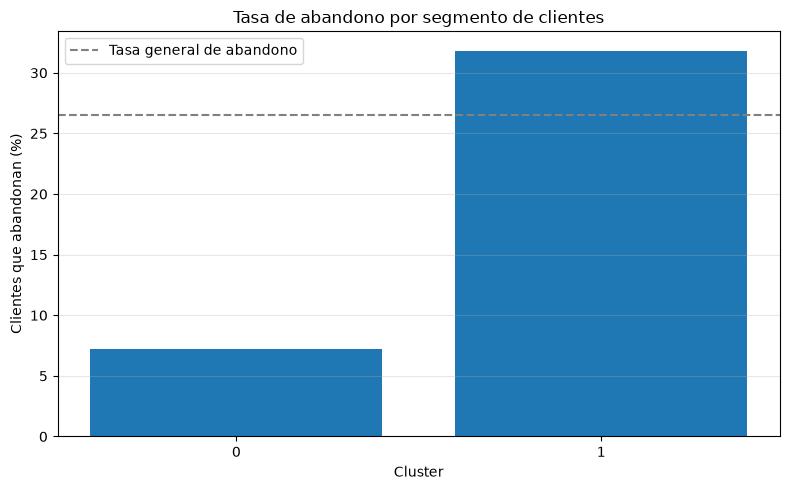

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    tasa_abandono_cluster.index.astype(str),
    tasa_abandono_cluster["Tasa de abandono (%)"]
)

plt.axhline(
    y=(train_segmentado["Churn"] == "Yes").mean() * 100,
    linestyle="--",
    color="gray",
    label="Tasa general de abandono"
)

plt.title("Tasa de abandono por segmento de clientes")
plt.xlabel("Cluster")
plt.ylabel("Clientes que abandonan (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de la tasa de abandono por segmento

El gráfico evidencia diferencias importantes en el comportamiento de abandono entre los dos segmentos identificados mediante K-Means.

El **Cluster 0** presenta una tasa de abandono aproximada del 7%, considerablemente inferior a la tasa general del conjunto Train, que corresponde al 26,54%. Esto indica que, dentro de los datos analizados, este segmento está compuesto principalmente por clientes que permanecen en la empresa.

En contraste, el **Cluster 1** presenta una tasa de abandono cercana al 32%, superior al promedio general. Este resultado sugiere que el grupo concentra un perfil de clientes que podría requerir mayor atención por parte de las estrategias de retención.

Desde la perspectiva comercial, el Cluster 1 podría priorizarse para analizar posibles acciones preventivas, mientras que el Cluster 0 puede estudiarse para identificar características asociadas con una mayor permanencia. Sin embargo, la pertenencia a un cluster no garantiza que un cliente abandone o permanezca, por lo que estos resultados deben interpretarse como patrones descriptivos y no como una predicción individual.


## Guardar resultados

In [42]:
ruta_modelos = ROOT / "models"
ruta_reportes = ROOT / "reports" / "clustering"

ruta_modelos.mkdir(parents=True, exist_ok=True)
ruta_reportes.mkdir(parents=True, exist_ok=True)

joblib.dump(
    preprocesador_cluster,
    ruta_modelos / "clustering_preprocessor.joblib"
)

joblib.dump(
    modelo_kmeans,
    ruta_modelos / "kmeans_customer_segmentation.joblib"
)

train_segmentado.to_csv(
    ruta_reportes / "train_customer_segments.csv",
    index=False
)

resultados_k.to_csv(
    ruta_reportes / "clustering_k_evaluation.csv",
    index=False
)

perfil_numerico.to_csv(
    ruta_reportes / "clustering_numeric_profiles.csv"
)

tabla_churn.to_csv(
    ruta_reportes / "clustering_churn_distribution.csv"
)

print("Modelo, preprocesador y resultados guardados correctamente.")
print("Carpeta:", ruta_reportes)

Modelo, preprocesador y resultados guardados correctamente.
Carpeta: c:\Users\fusk5\Desktop\telco-churn-ml\reports\clustering
